<a href="https://colab.research.google.com/github/oy-hotwater/sneaker-similar-image-search/blob/main/sneaker_similar_image_search_ver2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
# ==============================================================================
# セル1: 必要なライブラリのインストール
# ==============================================================================
!apt install -q libomp-dev
!pip install -q faiss-gpu-cu12  # CUDA 12系の場合
!pip install -q kaggle

Reading package lists...
Building dependency tree...
Reading state information...
libomp-dev is already the newest version (1:14.0-55~exp2).
0 upgraded, 0 newly installed, 0 to remove and 37 not upgraded.


In [2]:
# ==============================================================================
# セル2: Kaggle APIのセキュアな認証とデータセットの取得
# ==============================================================================
import os
import glob
import time
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# ⚠️ 厳格なセキュリティ管理: Colabの「シークレット」機能を使用する
try:
    from google.colab import userdata
    os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
    os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')
except Exception as e:
    raise SystemError("❌ エラー: Colabの左側メニュー「鍵」アイコン(シークレット)に、'KAGGLE_USERNAME' と 'KAGGLE_KEY' を登録してください。kaggle.jsonのアップロードは非推奨です。")

# Kaggle データセット名
DATASET_NAME = "nikolasgegenava/sneakers-classification"
DATA_DIR = "./dataset"

# 冪等性（何度実行しても安全な設計）の確保
if not os.path.exists(DATA_DIR):
    os.makedirs(DATA_DIR, exist_ok=True)
    print(f"Kaggle APIを使用して '{DATASET_NAME}' をダウンロード中...")

    # Kaggleからダウンロード
    !kaggle datasets download -d {DATASET_NAME} -p {DATA_DIR}

    zip_filename = DATASET_NAME.split('/')[-1] + ".zip"
    zip_path = os.path.join(DATA_DIR, zip_filename)

    print("ZIPファイルを展開中... (ブラウザクラッシュ防止のため出力を抑制しています)")
    # -q で出力を抑制、-n で既存ファイルの上書きをスキップ
    !unzip -q -n {zip_path} -d {DATA_DIR}

    # Colabのディスク容量を節約するためZIPを直ちに削除
    os.remove(zip_path)
    print("✅ データセットのダウンロードと展開が完了しました。")
else:
    print("✅ データセットは既に存在します。ダウンロードをスキップします。")

Kaggle APIを使用して 'nikolasgegenava/sneakers-classification' をダウンロード中...
Dataset URL: https://www.kaggle.com/datasets/nikolasgegenava/sneakers-classification
License(s): MIT
  0% 0.00/17.1M [00:00<?, ?B/s]
100% 17.1M/17.1M [00:00<00:00, 1.51GB/s]
ZIPファイルを展開中... (ブラウザクラッシュ防止のため出力を抑制しています)
✅ データセットのダウンロードと展開が完了しました。


In [3]:
# ==============================================================================
# セル3: データセットの堅牢な探索と破損ファイルの事前排除
# ==============================================================================
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

# GPUの稼働確認（プロの絶対条件）
gpus = tf.config.list_physical_devices('GPU')
if not gpus:
    raise SystemError("⚠️ GPUが認識されていません。Colabの「ランタイムのタイプを変更」から T4 GPU 等を選択してください。")
print(f"✅ GPU稼働確認完了: {len(gpus)} GPU(s) available.")

# 再帰的（Recursive）な画像検索。ディレクトリの深さに依存しない堅牢な設計。
all_image_paths = glob.glob(f"{DATA_DIR}/**/*.jpg", recursive=True)
# .jpeg や .png も含む場合は以下のように拡張します
all_image_paths.extend(glob.glob(f"{DATA_DIR}/**/*.jpeg", recursive=True))
all_image_paths.extend(glob.glob(f"{DATA_DIR}/**/*.png", recursive=True))

if len(all_image_paths) == 0:
    raise ValueError(f"❌ 画像が見つかりません。DATASET_NAME ({DATASET_NAME}) が正しいか確認してください。")

print(f"取得した画像パスの総数: {len(all_image_paths)}")

valid_image_paths = []
print("破損画像の事前チェックを実行中...")
for path in all_image_paths:
    try:
        with Image.open(path) as img:
            img.verify()
        valid_image_paths.append(path)
    except Exception:
        # 壊れた画像によるパイプラインの崩壊を防ぐ
        pass

print(f"✅ 処理対象の有効な画像数: {len(valid_image_paths)}")

✅ GPU稼働確認完了: 1 GPU(s) available.
取得した画像パスの総数: 5953
破損画像の事前チェックを実行中...
✅ 処理対象の有効な画像数: 5953


In [4]:
# ==============================================================================
# セル4: tf.data を用いた究極のI/Oパイプライン構築
# ==============================================================================
IMG_SIZE = (224, 224)
BATCH_SIZE = 64  # VRAMに応じて 128 や 256 に調整

def load_and_preprocess_image(path):
    img = tf.io.read_file(path)
    # pngなど多様なフォーマットに対応するため decode_image を使用し、RGB(3チャンネル)を強制
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = preprocess_input(img)
    return img

dataset = tf.data.Dataset.from_tensor_slices(valid_image_paths)
dataset = dataset.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
dataset = dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


In [5]:
# ==============================================================================
# セル5: モデルの構築と超高速特徴抽出
# ==============================================================================
base_model = ResNet50(weights='imagenet', include_top=False, pooling='avg')

print("特徴抽出を開始します。tf.dataパイプラインによりGPU稼働率は最大化されます...")
start_time = time.time()

# 予測実行
features = base_model.predict(dataset, verbose=1)

# L2正規化 (Faissでの内積検索=コサイン類似度検索にするための必須処理)
features = features / np.linalg.norm(features, axis=1, keepdims=True)

elapsed_time = time.time() - start_time
print(f"✅ 特徴抽出完了! 抽出時間: {elapsed_time:.2f}秒 ({(elapsed_time/len(valid_image_paths))*1000:.2f} ms/image)")
print(f"抽出された特徴量の形状: {features.shape}")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
特徴抽出を開始します。tf.dataパイプラインによりGPU稼働率は最大化されます...
94/94 ━━━━━━━━━━━━━━━━━━━━ 28s 197ms/step
✅ 特徴抽出完了! 抽出時間: 28.51秒 (4.79 ms/image)
抽出された特徴量の形状: (5953, 2048)


In [10]:
# ==============================================================================
# セル6: Faissを用いたベクトルインデックスの構築
# ==============================================================================
import faiss

dimension = features.shape[1]
index = faiss.IndexFlatIP(dimension) # 内積 (Inner Product) 計算用インデックス
index.add(np.ascontiguousarray(features))

print(f"✅ Faissインデックス構築完了: {index.ntotal} 件の画像ベクトルを登録")

✅ Faissインデックス構築完了: 5953 件の画像ベクトルを登録


検索クエリ: ./dataset/sneakers-dataset/sneakers-dataset/yeezy_boost_350_v2/0121.jpg
🔍 検索完了: 6.03 ミリ秒


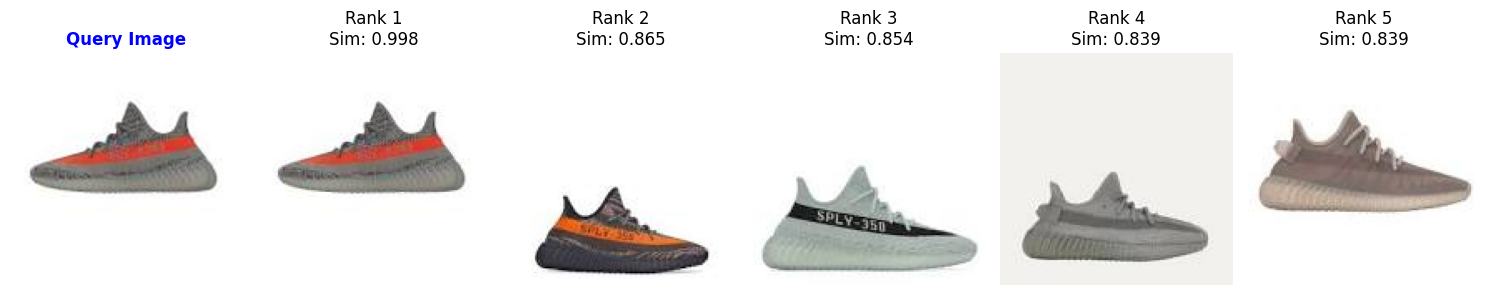

In [15]:
# ==============================================================================
# セル7: 類似画像検索の実行と可視化
# ==============================================================================
def search_similar_images(query_image_path, top_k=5):
    print(f"検索クエリ: {query_image_path}")

    # 1. クエリ画像の前処理と特徴抽出
    img = Image.open(query_image_path).convert('RGB').resize(IMG_SIZE)
    x = np.array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)

    query_feature = base_model.predict(x, verbose=0)
    query_feature = query_feature / np.linalg.norm(query_feature, axis=1, keepdims=True)

    # 2. Faissによる類似度検索 (数ミリ秒)
    start_search = time.time()
    distances, indices = index.search(np.ascontiguousarray(query_feature), top_k)
    search_time = time.time() - start_search
    print(f"🔍 検索完了: {search_time * 1000:.2f} ミリ秒")

    # 3. 結果の可視化
    plt.figure(figsize=(15, 5))

    # クエリ
    ax = plt.subplot(1, top_k + 1, 1)
    plt.imshow(img)
    plt.title("Query Image", fontweight='bold', color='blue')
    plt.axis("off")

    # 検索結果
    for i in range(top_k):
        idx = indices[0][i]
        score = distances[0][i]
        result_path = valid_image_paths[idx]

        try:
            result_img = Image.open(result_path).convert('RGB')
            ax = plt.subplot(1, top_k + 1, i + 2)
            plt.imshow(result_img)
            # 類似度(スコア)が高いほど似ている
            plt.title(f"Rank {i+1}\nSim: {score:.3f}")
            plt.axis("off")
        except Exception as e:
            print(f"画像の表示に失敗しました: {result_path}")

    plt.tight_layout()
    plt.show()

# テスト実行 (ランダムな画像をクエリとして検索)
if len(valid_image_paths) > 0:
    import random
    test_query_path = random.choice(valid_image_paths)
    search_similar_images(test_query_path, top_k=5)